In [11]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets
import torchvision.transforms as T

import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [4]:
# recursive permutation generator
def permutation(items):
    if len(items) == 0:
        return [[]]

    result = []
    for i in range(len(items)):
        current = items[i]
        rest = items[:i] + items[i+1:]

        s_perm = permutation(rest)
        for perm in s_perm:
            result.append([current] + perm)

    return result

permutation([1, 2, 3, 4])

[[1, 2, 3, 4],
 [1, 2, 4, 3],
 [1, 3, 2, 4],
 [1, 3, 4, 2],
 [1, 4, 2, 3],
 [1, 4, 3, 2],
 [2, 1, 3, 4],
 [2, 1, 4, 3],
 [2, 3, 1, 4],
 [2, 3, 4, 1],
 [2, 4, 1, 3],
 [2, 4, 3, 1],
 [3, 1, 2, 4],
 [3, 1, 4, 2],
 [3, 2, 1, 4],
 [3, 2, 4, 1],
 [3, 4, 1, 2],
 [3, 4, 2, 1],
 [4, 1, 2, 3],
 [4, 1, 3, 2],
 [4, 2, 1, 3],
 [4, 2, 3, 1],
 [4, 3, 1, 2],
 [4, 3, 2, 1]]

In [5]:
def generate_permutation(num_classes=24):
    all_perms = permutation(list(range(4)))
    all_perms = np.array(all_perms)

    selected_indices = [np.random.randint(0, len(all_perms))]

    for _ in range(1, num_classes):
        distances = np.zeros(len(all_perms))
        for idx in selected_indices:
            distances += np.sum(all_perms != all_perms[idx], axis=1)

        distances[selected_indices] = -1
        next_idx = np.argmax(distances, axis=0)
        selected_indices.append(next_idx)

    return all_perms[selected_indices]

PERMUTATIONS = torch.tensor(generate_permutation(), dtype=torch.long)

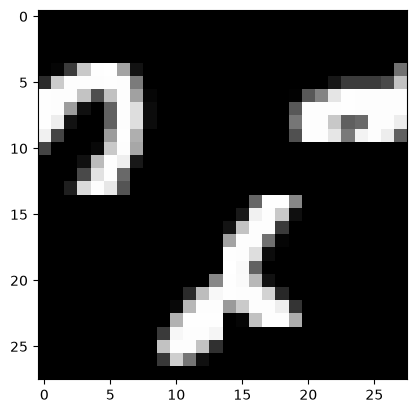

In [16]:
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.1307,), (0.3081,))
])

train_mnist_raw = datasets.MNIST(root="./data", train=True, download=False, transform=transform)

class JigsawMNISTDataset(Dataset):
    def __init__(self, base_dataset, permutation):
        super().__init__()
        self.dataset = base_dataset
        self.permutation = permutation

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]

        tiles = [
            img[:, 0:14, 0:14],
            img[:, 0:14, 14:28],
            img[:, 14:28, 0:14],
            img[:, 14:28, 14:28]
        ]
        
        label = torch.randint(0, len(self.permutation), (1,)).item()
        perm = self.permutation[label]
        
        shuffled_tiles = [tiles[i] for i in perm]
        
        top_row = torch.concatenate((shuffled_tiles[0], shuffled_tiles[1]), dim=2)
        bottom_row = torch.concatenate((shuffled_tiles[2], shuffled_tiles[3]), dim=2)
        jigsaw_img = torch.concatenate((top_row, bottom_row), dim=1)
        
        return jigsaw_img, label

train_dataset = JigsawMNISTDataset(train_mnist_raw, PERMUTATIONS)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

X, y = next(iter(train_loader))
plt.imshow(X[0].reshape(28, 28), cmap="grey");

In [17]:
class JigsawSolver(nn.Module):
    def __init__(self, num_classes=24):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), # (32, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # (32, 14, 14)
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (64, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2, 2) # (64, 7, 7)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x_embd = self.features(x)
        return self.classifier(x_embd)

model = JigsawSolver().to(device)
model(X.to(device)).shape

torch.Size([512, 24])

In [18]:
epochs = 10
optimizer = torch.optim.Adam(model.parameters())

history = []

for epoch in range(epochs):
    model.train()
    losses = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = F.cross_entropy(logits, y_batch)
        loss.backward()
        optimizer.step()

        losses.append(loss.detach().item())

    history.append(np.mean(losses))

    print(f"epoch: {epoch+1}, loss: {history[-1]}")

epoch: 1, loss: 0.25113172093564173
epoch: 2, loss: 0.03878531032005104
epoch: 3, loss: 0.02663165741300179
epoch: 4, loss: 0.021395634725626746
epoch: 5, loss: 0.0168827692613053


KeyboardInterrupt: 